In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\SUDHI S R\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
import seaborn as sns

In [4]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.shape

(891, 12)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
#count the duplicate value

df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [10]:
#how many null values are there

print(df.isnull().sum())
m = df.isnull().sum()
print(m)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


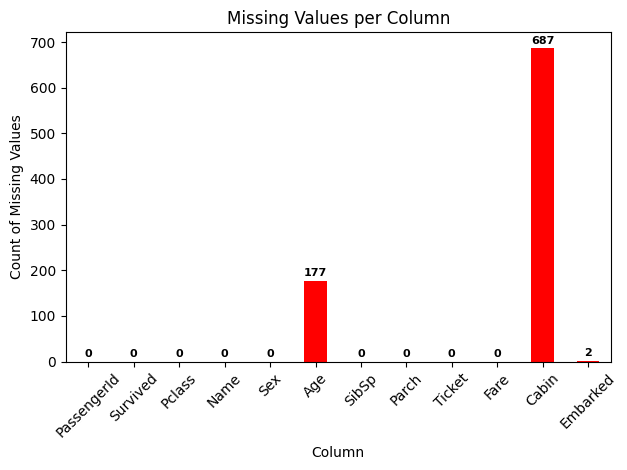

In [11]:
# Create the bar plot
a = m.plot(kind='bar', color='red')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)

for index, value in enumerate(m):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
#cabin has more null value 

#so we can drop cabin columns 

df = df.drop(columns =["Cabin"])

In [13]:
#age has 177 missing 

df['Age'] = df['Age'].fillna(df['Age'].median())

In [14]:
#embarked has 2 missing it can be solved by mode way

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
#count if survival person 
survived = df['Survived'].value_counts()
print('survived count: \n',survived )

survived count: 
 Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_17952\898867364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='dark')


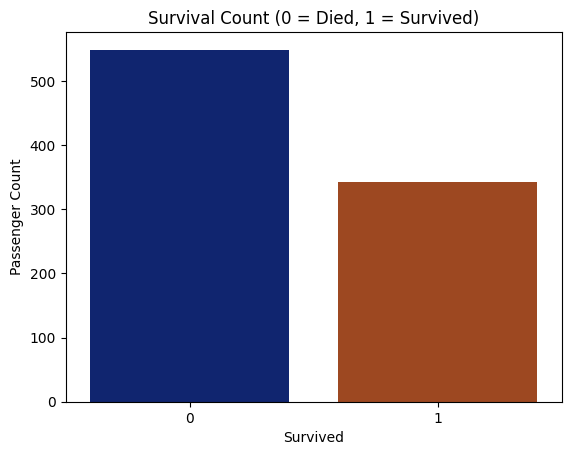

In [17]:
#plot it in bar graph using seaborn

sns.countplot(x='Survived', data=df, palette='dark')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()

In [18]:
#survived by gender 

gender = df['Sex'].value_counts()
print("\nGender Counts:\n", gender)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [19]:
#survived by gender 

survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)


Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


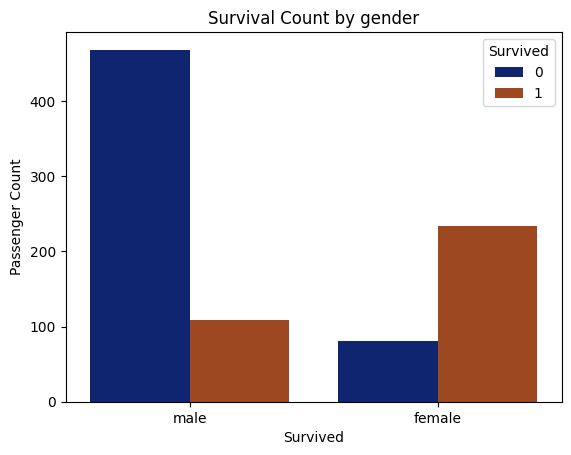

In [20]:
sns.countplot(x='Sex', hue ='Survived', data=df, palette='dark')
plt.title('Survival Count by gender')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [21]:
# Count of passengers by class


pclass = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass)


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


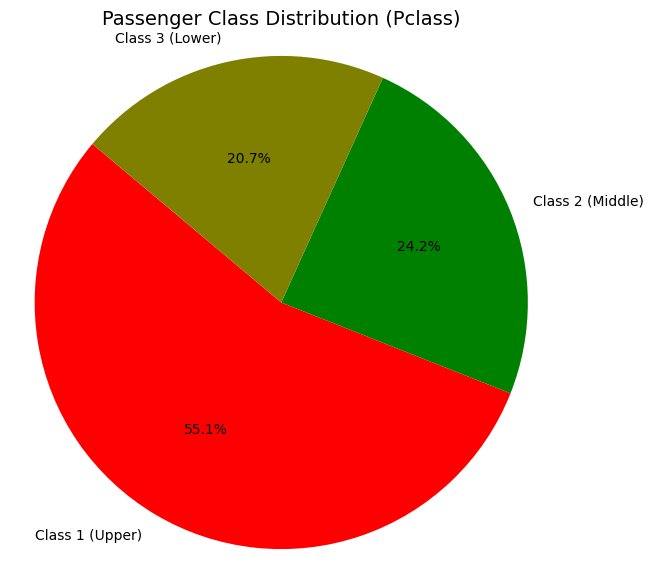

In [22]:
# Labels for the pie chart
labels = ['Class 1 (Upper)', 'Class 2 (Middle)', 'Class 3 (Lower)']

plt.figure(figsize=(7, 7))
plt.pie(pclass, labels=labels, autopct='%1.1f%%', startangle=140, colors=['red', 'green', 'olive'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal') 
plt.show()

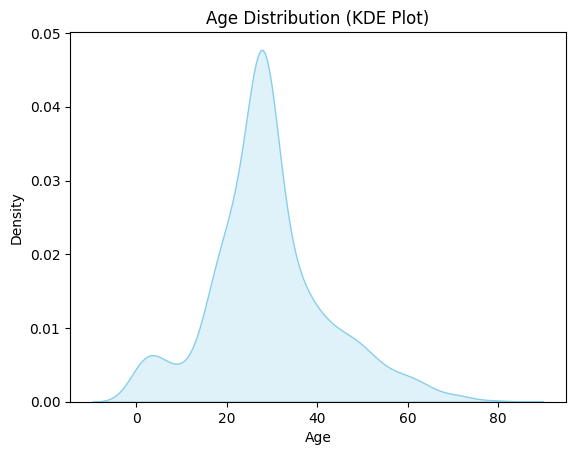

In [23]:
#age distribution

sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

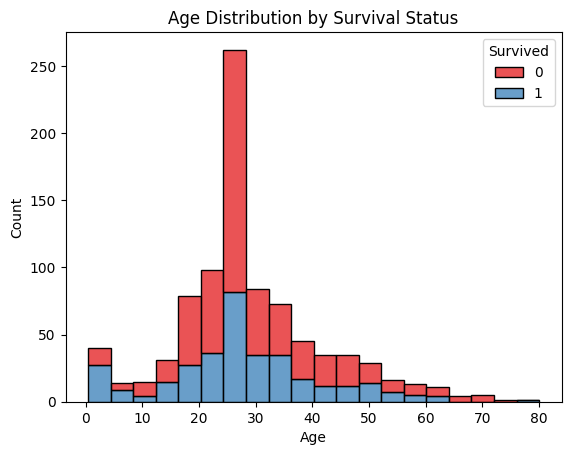

In [24]:
#Age vs survived

sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

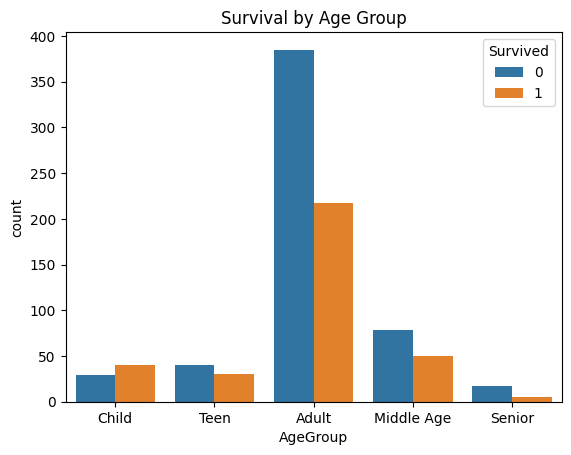

In [25]:
#survived by age group 

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])
sns.countplot(x='AgeGroup', hue='Survived', data=df)
plt.title('Survival by Age Group')
plt.show()

In [26]:
#embared count 

embarked = df['Embarked'].value_counts()
print("Embarked count : \n",embarked)

Embarked count : 
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_17952\3275970544.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Embarked', data=df, palette='dark')
C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_17952\3275970544.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


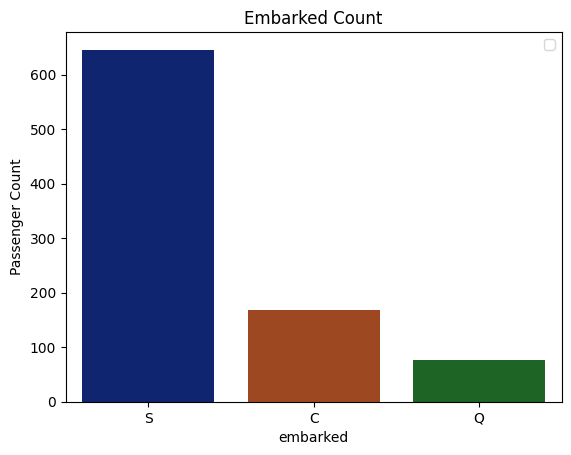

In [27]:
#plot in  Embarked count

sns.countplot(x='Embarked', data=df, palette='dark')
plt.title('Embarked Count')
plt.xlabel('embarked')
plt.ylabel('Passenger Count')
plt.legend()

#for index , value in enumerate('Embarked'):
    #plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

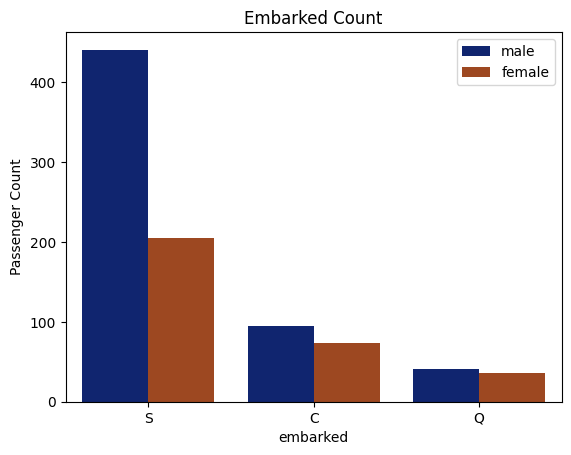

In [28]:
#plot with sex in Embarked count 

sns.countplot(x='Embarked', hue ='Sex' ,data=df, palette='dark')
plt.title('Embarked Count')
plt.xlabel('embarked')
plt.ylabel('Passenger Count')
plt.legend()
plt.show()

In [29]:
Ticket_count = df['Ticket'].value_counts()
print("Ticket Count: \n",Ticket_count)

Ticket Count: 
 Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64


In [30]:
Ticket_count = df['Ticket'].value_counts()
print("Ticket Count: \n",Ticket_count)


Ticket Count: 
 Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64
